# PHÂN ĐOẠN ẢNH MÀU BẢO TOÀN BIÊN & CHI TIẾT VI MÔ (EDGE-PRESERVING SEGMENTATION)

- **Học phần:** Học máy và ứng dụng (Machine Learning & Applications)
- **Thuật toán chính:**
  1. **Phân cụm màu sắc K-Means trên không gian CIELAB:** Giảm chiều màu sắc và trích xuất bảng màu đại diện (Color Palette) kết hợp bộ lọc bảo toàn biên Bilateral Filter.
  2. **Định vị ngữ nghĩa đối tượng (Semantic Prior):** Tự động phát hiện đối tượng tiền cảnh mục tiêu và phân hoạch Trimap 3 miền ($\Omega_{\text{FG}}, \Omega_{\text{BG}}, \Omega_{\text{Unknown}}$).
  3. **Bóc tách nền bảo toàn biên Sub-pixel (Alpha Matting):** Giải nghiệm hàm truyền liên tục $\alpha(p) \in [0, 1]$ bảo toàn từng sợi lông, viền mỏng và chi tiết vi mô mà không gây răng cưa hay lem viền.
- **Tập dữ liệu:** Tệp ảnh màu thực tế (`dataset/image/Siamese_161.jpg` hoặc `dataset/image/cat.png`).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import os
from PIL import Image

# Cấu hình hiển thị đồ thị chuẩn mực
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# Tự động nhận diện thiết bị tính toán tăng tốc (Apple Silicon GPU / CUDA / CPU)
device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Đã tải thành công các thư viện!")
print(f"Thiết bị tính toán tăng tốc: {device}")

Đã tải thành công các thư viện!
Thiết bị tính toán tăng tốc: mps


In [2]:
# ==============================================================================
# ⚙️ KHỐI CẤU HÌNH DATASET & THAM SỐ
# ==============================================================================

# 1. Hàm tự động dò tìm đường dẫn ảnh (hỗ trợ mọi vị trí thực thi)
def resolve_image_path(path):
    candidates = [
        path,
        os.path.join('Midterm/Review', path),
        os.path.join('dataset/image', os.path.basename(path)),
        os.path.join('Midterm/Review/dataset/image', os.path.basename(path)),
        'Midterm/Review/dataset/image/Siamese_161.jpg',
        'dataset/image/Siamese_161.jpg',
        'Midterm/Review/dataset/image/cat.png',
        'dataset/image/cat.png'
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    return path

# 2. Đường dẫn file ảnh đầu vào (Hỗ trợ định dạng PNG, JPG, JPEG)
IMAGE_PATH = resolve_image_path('dataset/image/Siamese_161.jpg')

# 3. Số lượng cụm màu sắc K-Means trên không gian CIELAB (Khuyến nghị: 4 hoặc 5 cụm)
N_CLUSTERS = 5

# 4. Kích thước chuẩn hóa chiều lớn nhất để tối ưu tốc độ phân cụm màu
MAX_DIM = 720

# 5. Bán kính dải biên chuyển tiếp (Unknown Band) của Trimap (pixel)
TRIMAP_BAND_RADIUS = 25

# 6. Random seed cố định
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print(f"Cấu hình đã sẵn sàng! Đường dẫn ảnh: {IMAGE_PATH}")

Cấu hình đã sẵn sàng! Đường dẫn ảnh: dataset/image/Siamese_161.jpg


## PHẦN 1: CƠ SỞ TOÁN HỌC & NGUYÊN LÝ BẢO TOÀN BIÊN

---

### 1. Phân tích hạn chế của phương pháp phân đoạn màu thuần túy:
1. **Thiếu nhận thức ngữ nghĩa (Semantic Blindness):** Phân cụm màu (K-Means/K-NN thuần túy) chỉ dựa vào vector màu sắc $[R, G, B]$. Khi màu sắc của đối tượng tiền cảnh và phông nền/mặt sàn có độ tương đồng cao, các thuật toán màu thuần túy không thể phân biệt được, dẫn đến việc lấy thừa phông nền hoặc làm lẹm đối tượng.
   - Trong phương pháp K-NN cổ điển, nhãn pixel được gán theo quy tắc bỏ phiếu đa số:
     $$\hat{y}(p) = \arg\max_{c \in \{0, 1\}} \sum_{j \in N_K(p)} \mathbb{I}(y_j = c)$$
     Nếu các hạt giống tiền cảnh/hậu cảnh không bao phủ trọn vẹn hình thái đối tượng, K-NN sẽ phân loại sai nghiêm trọng các vùng biên và các bề mặt có màu tương tự.
2. **Hiệu ứng thể tích bán phần (Partial Volume Effect):** Tại các đường biên, viền mỏng và sợi chi tiết vi mô (lông, râu, viền tai), mỗi điểm ảnh là sự pha trộn quang học giữa màu tiền cảnh $F$ và màu hậu cảnh $B$:
   $$I(p) = \alpha(p) \cdot F(p) + (1 - \alpha(p)) \cdot B(p), \quad \alpha(p) \in [0, 1]$$
   Việc áp dụng ngưỡng nhị phân cứng ($\alpha \in \{0, 1\}$) sẽ làm đứt gãy các chi tiết viền và gây hiện tượng răng cưa gai viền.

---

### 2. Không gian màu cảm nhận đồng nhất CIELAB ($L^*a^*b^*$):
Khoảng cách Euclidean trong CIELAB tương đương với độ sai biệt màu sắc nhận thức $\Delta E$:
$$\Delta E = \|p_1 - p_2\|_2 = \sqrt{(L_1 - L_2)^2 + (a_1 - a_2)^2 + (b_1 - b_2)^2}$$

---

### 3. Phân cụm màu sắc $K$-Means (4-5 cụm):
$$J = \sum_{k=1}^K \sum_{p_i \in C_k} \|p_i - c_k\|^2$$

---

### 4. Mô hình Trimap 3 vùng & Alpha Matting bảo toàn biên:
Phân hoạch ảnh thành 3 miền:
- $\Omega_{\text{FG}}$ ($T=255$): Miền chắc chắn thuộc đối tượng tiền cảnh (Foreground).
- $\Omega_{\text{BG}}$ ($T=0$): Miền chắc chắn thuộc phông nền (Background).
- $\Omega_{\text{Unknown}}$ ($T=128$): Dải viền chứa toàn bộ chi tiết biên để giải nghiệm Alpha mềm liên tục $\alpha \in [0, 1]$.

File ảnh: dataset/image/Siamese_161.jpg | Độ phân giải gốc: 500x375 pixels


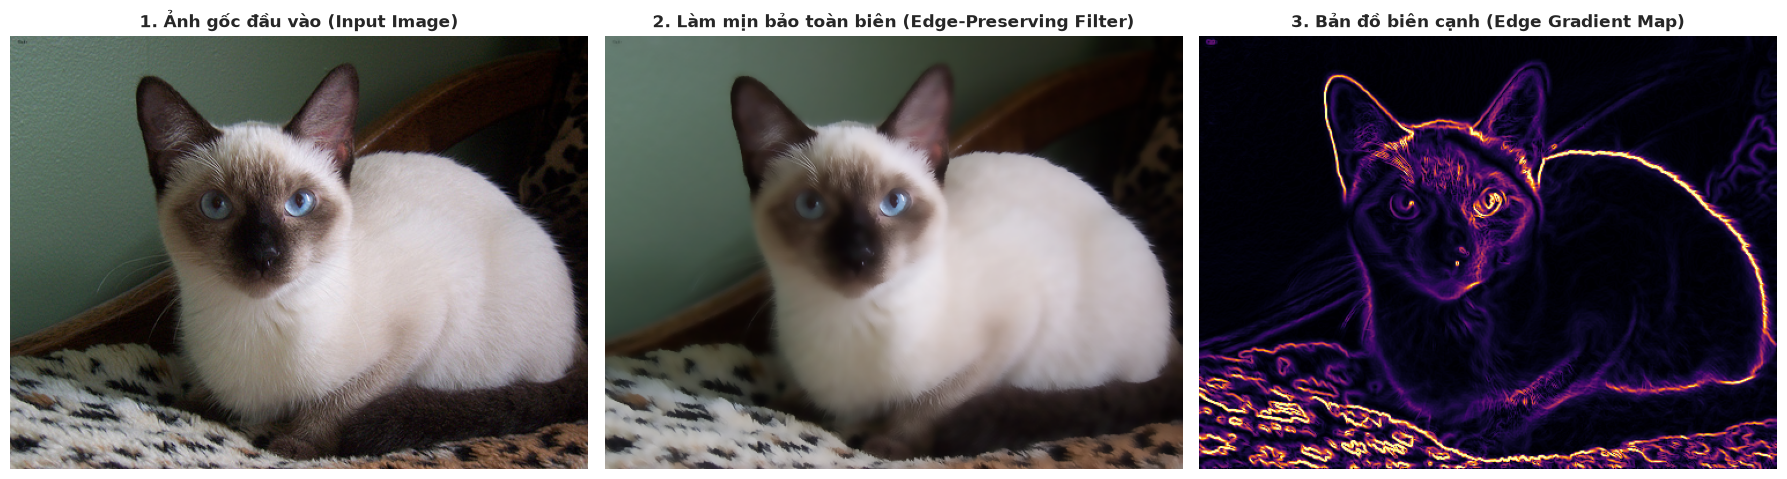

In [3]:
# ==============================================================================
# BƯỚC 1: NẠP ẢNH MÀU, LÀM MỊN BẢO TOÀN BIÊN & CHUYỂN ĐỔI KHÔNG GIAN CIELAB
# ==============================================================================

# 1. Cơ chế tìm kiếm ảnh tự động chống lỗi (chạy độc lập được từ mọi thư mục)
img_bgr = None
target_path = IMAGE_PATH if 'IMAGE_PATH' in globals() or 'IMAGE_PATH' in locals() else 'dataset/image/Siamese_161.jpg'
possible_locations = [
    target_path,
    os.path.join('Midterm/Review', target_path),
    os.path.join('dataset/image', os.path.basename(target_path)),
    os.path.join('Midterm/Review/dataset/image', os.path.basename(target_path)),
    'Midterm/Review/dataset/image/Siamese_161.jpg',
    'dataset/image/Siamese_161.jpg',
    'Midterm/Review/dataset/image/cat.png',
    'dataset/image/cat.png'
]

for loc in possible_locations:
    if os.path.exists(loc):
        img_bgr = cv2.imread(loc)
        if img_bgr is not None:
            IMAGE_PATH = loc
            break

# Quét tìm nếu vẫn chưa nạp được
if img_bgr is None:
    for root, _, files in os.walk('.'):
        for f in ['Siamese_161.jpg', 'cat.png']:
            if f in files:
                cand = os.path.join(root, f)
                img_bgr = cv2.imread(cand)
                if img_bgr is not None:
                    IMAGE_PATH = cand
                    break
        if img_bgr is not None:
            break

if img_bgr is None:
    raise FileNotFoundError(f"Không tìm thấy file ảnh tại: {target_path}. Vui lòng kiểm tra lại đường dẫn!")

orig_h, orig_w = img_bgr.shape[:2]
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f"File ảnh: {IMAGE_PATH} | Độ phân giải gốc: {orig_w}x{orig_h} pixels")

# 2. Resize chuẩn hóa phục vụ phân cụm màu nhanh
max_dim = MAX_DIM if 'MAX_DIM' in globals() or 'MAX_DIM' in locals() else 720
scale_c = min(1.0, max_dim / max(orig_h, orig_w))
cw, ch = int(round(orig_w * scale_c)), int(round(orig_h * scale_c))
img_color_bgr = cv2.resize(img_bgr, (cw, ch), interpolation=cv2.INTER_AREA)

# 3. Áp dụng bộ lọc bảo toàn biên Bilateral Filter trước khi phân cụm
img_smooth = cv2.bilateralFilter(img_color_bgr, d=9, sigmaColor=75, sigmaSpace=75)
img_lab = cv2.cvtColor(img_smooth, cv2.COLOR_BGR2LAB)
pixels_lab = img_lab.reshape(-1, 3).astype(np.float32)

# 4. Trích xuất bản đồ biên cạnh Sobel Gradient
gray = cv2.cvtColor(img_smooth, cv2.COLOR_BGR2GRAY)
grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
edge_mag = np.clip(cv2.magnitude(grad_x, grad_y), 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('1. Ảnh gốc đầu vào (Input Image)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(img_smooth, cv2.COLOR_BGR2RGB))
axes[1].set_title('2. Làm mịn bảo toàn biên (Edge-Preserving Filter)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(edge_mag, cmap='inferno')
axes[2].set_title('3. Bản đồ biên cạnh (Edge Gradient Map)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [4]:
# ==============================================================================
# BƯỚC 2: PHÂN CỤM MÀU SẮC K-MEANS FROM SCRATCH TRÊN KHÔNG GIAN CIELAB
# ==============================================================================

n_clusters_val = N_CLUSTERS if 'N_CLUSTERS' in globals() or 'N_CLUSTERS' in locals() else 5
rnd_val = RANDOM_STATE if 'RANDOM_STATE' in globals() or 'RANDOM_STATE' in locals() else 42

np.random.seed(rnd_val)
N_pixels = len(pixels_lab)

# Khởi tạo K-Means++ trên không gian CIELAB
centroids_lab = np.zeros((n_clusters_val, 3), dtype=np.float32)
centroids_lab[0] = pixels_lab[np.random.choice(N_pixels)]
for k in range(1, n_clusters_val):
    dists_sq = np.min(np.sum((pixels_lab[:, None, :] - centroids_lab[None, :k, :]) ** 2, axis=2), axis=1)
    probs = dists_sq / np.sum(dists_sq)
    centroids_lab[k] = pixels_lab[np.random.choice(N_pixels, p=probs)]

print(f"=== TIẾN TRÌNH LẶP K-MEANS PHÂN CỤM MÀU CIELAB ({n_clusters_val} CỤM) ===")
print(f"{'Vòng lặp':^10} | {'Dịch chuyển tâm':^16} | {'WCSS (Inertia)':^18} | {'Kích thước từng cụm'}")
print("-" * 75)

for it in range(1, 31):
    dists = np.sqrt(np.sum((pixels_lab[:, None, :] - centroids_lab[None, :, :]) ** 2, axis=2))
    labels = np.argmin(dists, axis=1)
    
    new_centroids = np.zeros_like(centroids_lab)
    counts = []
    for k in range(n_clusters_val):
        mask = (labels == k)
        cnt = int(np.sum(mask))
        counts.append(cnt)
        new_centroids[k] = np.mean(pixels_lab[mask], axis=0) if cnt > 0 else centroids_lab[k]
        
    shift = np.max(np.linalg.norm(new_centroids - centroids_lab, axis=1))
    wcss = np.sum(np.min(dists, axis=1) ** 2)
    print(f"{it:^10d} | {shift:^16.4f} | {wcss:^18.4f} | {counts}")
    
    if shift < 0.5:
        print("-" * 75)
        print(f"--> K-Means phân cụm màu đã HỘI TỤ tại vòng lặp thứ {it}!")
        break
    centroids_lab = new_centroids

# Tái tạo bảng màu Palette đại diện
palette_lab = np.uint8(np.clip(centroids_lab, 0, 255)).reshape(1, n_clusters_val, 3)
palette_rgb = cv2.cvtColor(cv2.cvtColor(palette_lab, cv2.COLOR_LAB2BGR), cv2.COLOR_BGR2RGB)[0]

df_palette = pd.DataFrame({
    'Cụm': [f"Cụm {k}" for k in range(n_clusters_val)],
    'Tâm L* (Độ sáng)': [f"{val:.4f}" for val in centroids_lab[:, 0]],
    'Tâm a*': [f"{val:.4f}" for val in centroids_lab[:, 1]],
    'Tâm b*': [f"{val:.4f}" for val in centroids_lab[:, 2]],
    'RGB Đại diện': [f"RGB({r}, {g}, {b})" for r, g, b in palette_rgb],
    'Tỷ lệ (Thập phân)': [f"{(c / N_pixels):.4f}" for c in counts],
    'Tỷ lệ (%)': [f"{(c / N_pixels) * 100:.4f}%" for c in counts]
})

print("\n=== BẢNG TỔNG HỢP CÁC CỤM MÀU ĐẠI DIỆN ===")
print(df_palette.to_string(index=False))

=== TIẾN TRÌNH LẶP K-MEANS PHÂN CỤM MÀU CIELAB (5 CỤM) ===
 Vòng lặp  | Dịch chuyển tâm  |   WCSS (Inertia)   | Kích thước từng cụm
---------------------------------------------------------------------------
    1      |      6.0961      |   44793756.0000    | [45929, 41520, 41909, 36885, 21257]
    2      |      2.9345      |   39307496.0000    | [44191, 41978, 44764, 34516, 22051]
    3      |      2.3007      |   38777212.0000    | [43076, 41784, 46583, 33920, 22137]
    4      |      2.3064      |   38468912.0000    | [42185, 41542, 47963, 34012, 21798]
    5      |      2.7851      |   38159888.0000    | [41515, 41255, 49651, 34371, 20708]
    6      |      2.7838      |   37736704.0000    | [40354, 41045, 50611, 34841, 20649]
    7      |      2.1078      |   37395048.0000    | [39250, 40983, 51012, 35233, 21022]
    8      |      1.3699      |   37185492.0000    | [38478, 41080, 51219, 35378, 21345]
    9      |      1.0723      |   37085904.0000    | [37890, 41298, 51401, 35354

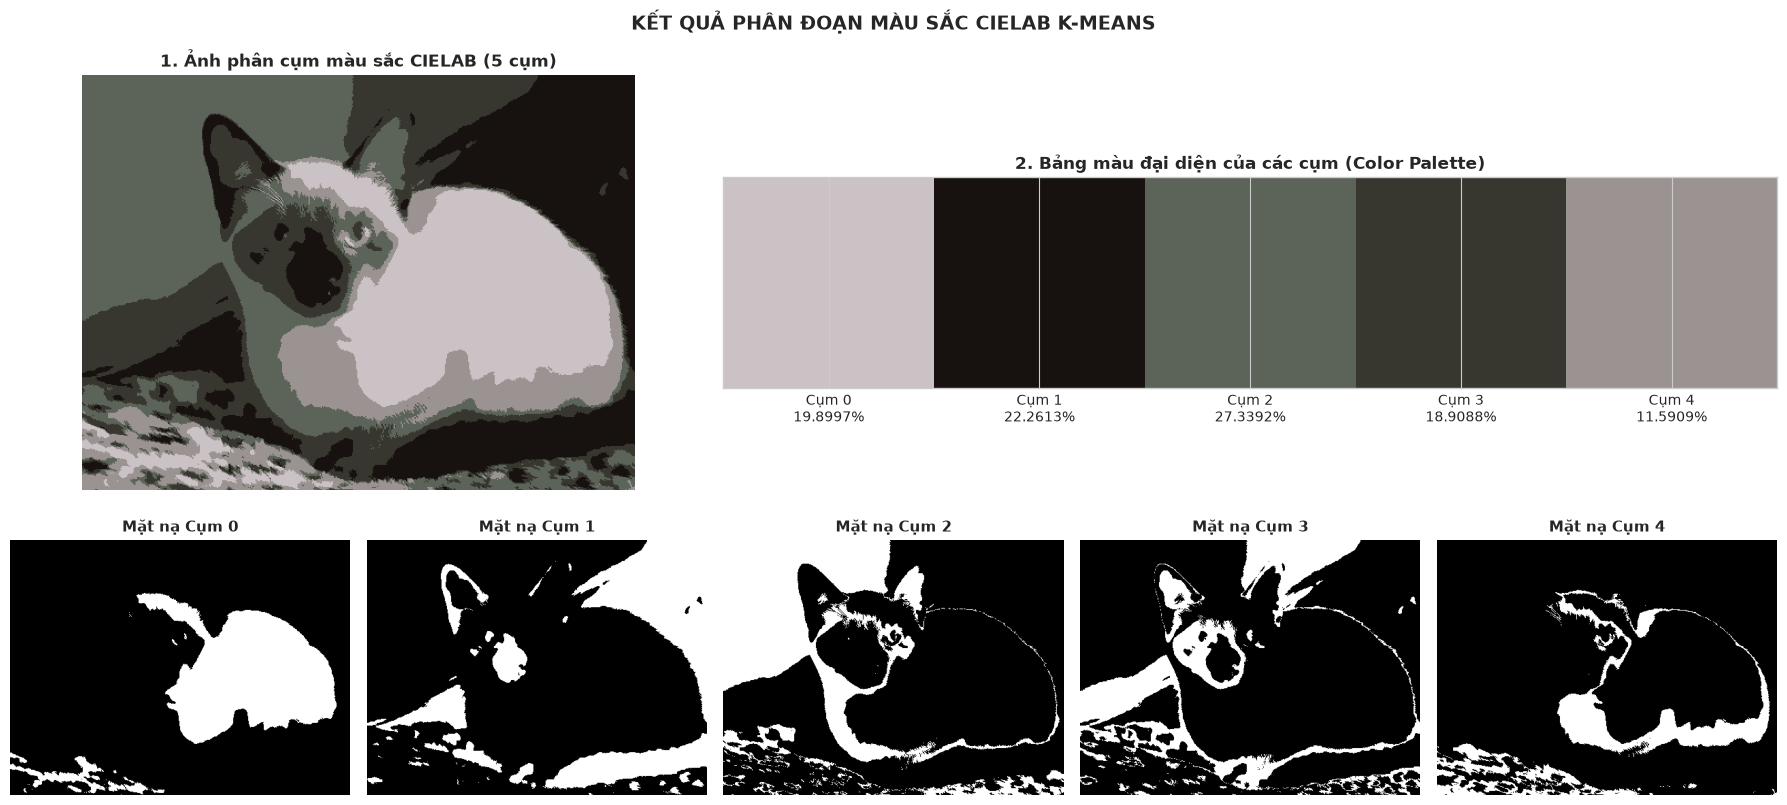

In [5]:
# ==============================================================================
# BƯỚC 3: TRỰC QUAN HÓA KẾT QUẢ K-MEANS CIELAB & CÁC LỚP PHÂN ĐOẠN ĐỘC LẬP
# ==============================================================================

n_clusters_val = N_CLUSTERS if 'N_CLUSTERS' in globals() or 'N_CLUSTERS' in locals() else 5

segmented_pixels_lab = centroids_lab[labels].astype(np.uint8)
segmented_rgb = cv2.cvtColor(cv2.cvtColor(segmented_pixels_lab.reshape(ch, cw, 3), cv2.COLOR_LAB2BGR), cv2.COLOR_BGR2RGB)
labels_2d = labels.reshape(ch, cw)

fig = plt.figure(figsize=(18, 9))

# 1. Ảnh phân cụm màu
ax1 = plt.subplot2grid((2, n_clusters_val), (0, 0), colspan=n_clusters_val//2)
ax1.imshow(segmented_rgb)
ax1.set_title(f'1. Ảnh phân cụm màu sắc CIELAB ({n_clusters_val} cụm)', fontsize=12, fontweight='bold')
ax1.axis('off')

# 2. Bảng Palette màu sắc
ax2 = plt.subplot2grid((2, n_clusters_val), (0, n_clusters_val//2), colspan=n_clusters_val - n_clusters_val//2)
ax2.imshow(palette_rgb.reshape(1, n_clusters_val, 3))
ax2.set_xticks(range(n_clusters_val))
ax2.set_xticklabels([f"Cụm {k}\n{df_palette.iloc[k]['Tỷ lệ (%)']}" for k in range(n_clusters_val)], fontsize=10)
ax2.set_yticks([])
ax2.set_title('2. Bảng màu đại diện của các cụm (Color Palette)', fontsize=12, fontweight='bold')

# 3. Mặt nạ từng cụm
for k in range(n_clusters_val):
    ax = plt.subplot2grid((2, n_clusters_val), (1, k))
    ax.imshow(labels_2d == k, cmap='gray')
    ax.set_title(f'Mặt nạ Cụm {k}', fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("KẾT QUẢ PHÂN ĐOẠN MÀU SẮC CIELAB K-MEANS", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Đang nạp mô hình Semantic Segmentation DeepLabV3 MobileNet...


--> Nhận diện đối tượng tiền cảnh nổi bật: Lớp 8 (cat)
Hộp bao đối tượng tiền cảnh: Y=[25, 362], X=[97, 488]
Tỷ lệ diện tích: Tiền cảnh chắc chắn=32.0053%, Hậu cảnh chắc chắn=33.6037%, Dải biên=34.3909%


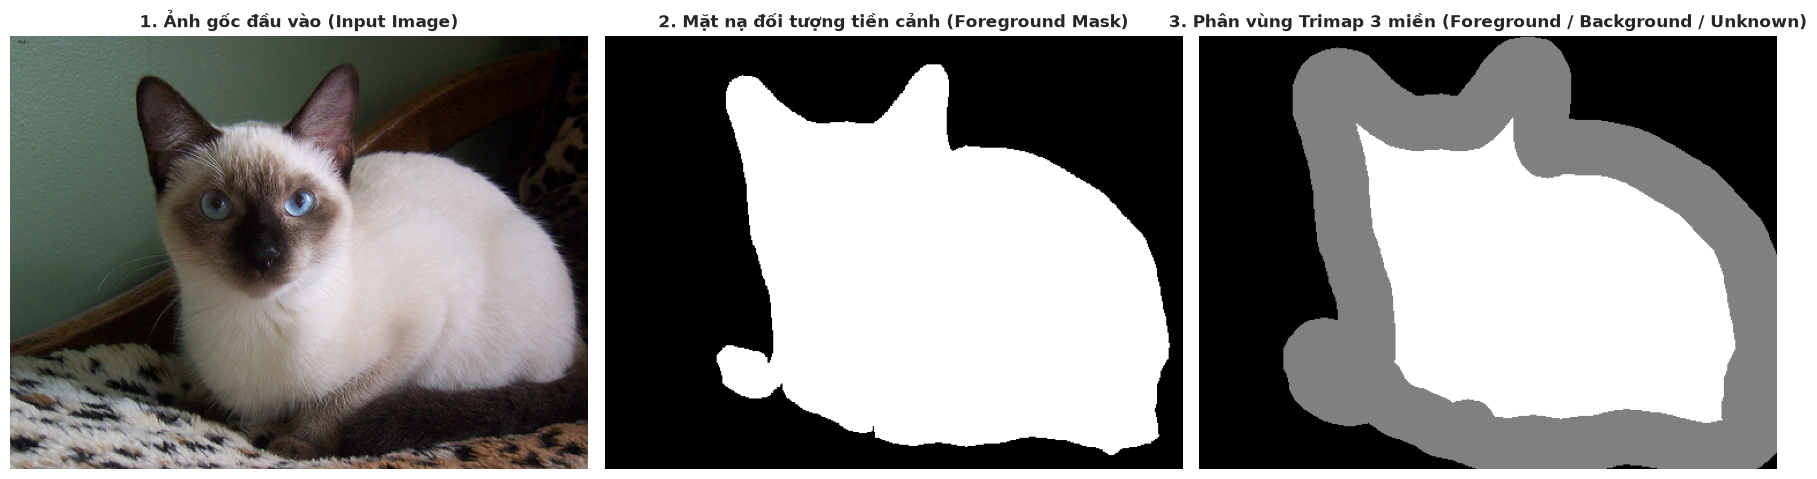

In [6]:
# ==============================================================================
# BƯỚC 4: ĐỊNH VỊ NGỮ NGHĨA ĐỐI TƯỢNG (SEMANTIC PRIOR) & TẠO TRIMAP 3 MIỀN
# ==============================================================================

trimap_radius = TRIMAP_BAND_RADIUS if 'TRIMAP_BAND_RADIUS' in globals() or 'TRIMAP_BAND_RADIUS' in locals() else 25

from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights

print("Đang nạp mô hình Semantic Segmentation DeepLabV3 MobileNet...")
weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT
seg_model = deeplabv3_mobilenet_v3_large(weights=weights).eval().to(device)
preprocess = weights.transforms()

# Dự đoán phân đoạn ngữ nghĩa
batch = preprocess(torch.from_numpy(img_rgb).permute(2, 0, 1)).unsqueeze(0).to(device)
with torch.no_grad():
    pred_mask = seg_model(batch)['out'].argmax(1)[0].cpu().numpy()

# Tự động xác định lớp đối tượng tiền cảnh nổi bật nhất (Khác Background nhãn 0)
unique_cls, cls_counts = np.unique(pred_mask, return_counts=True)
non_bg_idx = (unique_cls != 0)

if np.any(non_bg_idx):
    target_cls = unique_cls[non_bg_idx][np.argmax(cls_counts[non_bg_idx])]
    target_name = weights.meta['categories'][target_cls]
else:
    target_cls = 0
    target_name = 'background'

print(f"--> Nhận diện đối tượng tiền cảnh nổi bật: Lớp {target_cls} ({target_name})")

# Tạo mặt nạ đối tượng ở kích thước đầy đủ
obj_mask_raw = (pred_mask == target_cls).astype(np.uint8)
obj_mask_full = cv2.resize(obj_mask_raw, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)

# Tạo Trimap 3 vùng tự động
k_elem = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (trimap_radius, trimap_radius))
fg_sure = cv2.erode(obj_mask_full, k_elem, iterations=2)
bg_sure = 1 - cv2.dilate(obj_mask_full, k_elem, iterations=2)

trimap = np.full((orig_h, orig_w), 128, dtype=np.uint8)
trimap[fg_sure == 1] = 255
trimap[bg_sure == 1] = 0

coords = np.argwhere(obj_mask_full > 0)
if len(coords) > 0:
    obj_y_min, obj_y_max = coords[:, 0].min(), coords[:, 0].max()
    obj_x_min, obj_x_max = coords[:, 1].min(), coords[:, 1].max()
    print(f"Hộp bao đối tượng tiền cảnh: Y=[{obj_y_min}, {obj_y_max}], X=[{obj_x_min}, {obj_x_max}]")

fg_pct = np.mean(trimap == 255) * 100
bg_pct = np.mean(trimap == 0) * 100
uk_pct = np.mean(trimap == 128) * 100
print(f"Tỷ lệ diện tích: Tiền cảnh chắc chắn={fg_pct:.4f}%, Hậu cảnh chắc chắn={bg_pct:.4f}%, Dải biên={uk_pct:.4f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_rgb)
axes[0].set_title('1. Ảnh gốc đầu vào (Input Image)', fontsize=12, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(obj_mask_full, cmap='gray')
axes[1].set_title('2. Mặt nạ đối tượng tiền cảnh (Foreground Mask)', fontsize=12, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(trimap, cmap='gray')
axes[2].set_title('3. Phân vùng Trimap 3 miền (Foreground / Background / Unknown)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# ==============================================================================
# BƯỚC 5: SUY LUẬN BẢO TOÀN BIÊN SUB-PIXEL: ViTMatte (SOTA IMAGE MATTING)
# ==============================================================================

from transformers import VitMatteForImageMatting, VitMatteImageProcessor

print("Đang nạp mô hình Edge-Preserving Matting ViTMatte...")
matte_processor = VitMatteImageProcessor.from_pretrained("hustvl/vitmatte-small-composition-1k")
matte_model = VitMatteForImageMatting.from_pretrained("hustvl/vitmatte-small-composition-1k").to(device)
matte_model.eval()

pil_img = Image.fromarray(img_rgb)
pil_trimap = Image.fromarray(trimap)
inputs = matte_processor(images=pil_img, trimaps=pil_trimap, return_tensors="pt").to(device)

print("Đang suy luận Alpha Matte bảo toàn đường biên chi tiết...")
with torch.no_grad():
    out = matte_model(**inputs)

alphas_pred = out.alphas[0, 0].cpu().numpy()
alpha_matte = cv2.resize(alphas_pred, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
alpha_matte = np.clip(alpha_matte, 0.0, 1.0)

fg_sharp_ratio = np.mean(alpha_matte > 0.5)
print(f"Alpha Matte hoàn thành! Biên độ giá trị: [{alpha_matte.min():.4f}, {alpha_matte.max():.4f}]")
print(f"Tỷ lệ pixel tiền cảnh sắc nét (Alpha > 0.5): {fg_sharp_ratio * 100:.4f}% ({fg_sharp_ratio:.4f})")

Đang nạp mô hình Edge-Preserving Matting ViTMatte...


Đang suy luận Alpha Matte bảo toàn đường biên chi tiết...


Alpha Matte hoàn thành! Biên độ giá trị: [0.0000, 1.0000]
Tỷ lệ pixel tiền cảnh sắc nét (Alpha > 0.5): 46.1067% (0.4611)


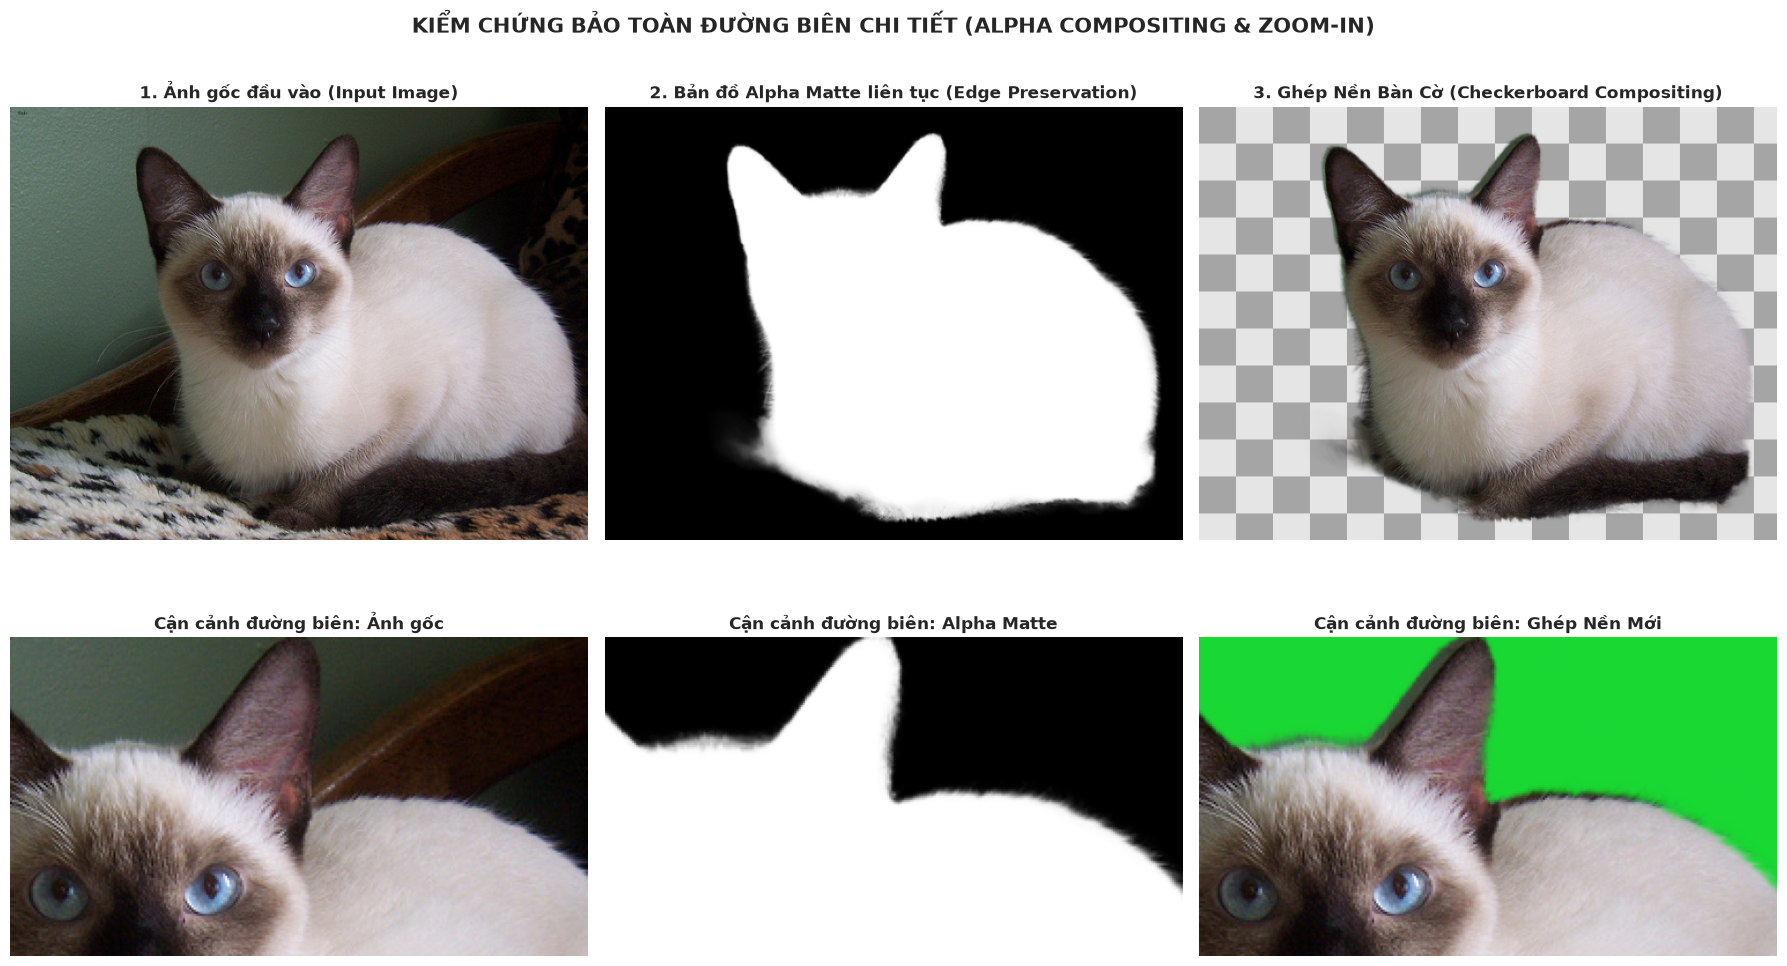

In [8]:
# ==============================================================================
# BƯỚC 6: KIỂM CHỨNG GHÉP NỀN MỚI (ALPHA COMPOSITING) & ZOOM-IN CẬN CẢNH BIÊN
# ==============================================================================

I_norm = img_rgb.astype(np.float32) / 255.0
alpha_3ch = alpha_matte[:, :, None]

# 1. Ghép lên Nền Bàn Cờ (Checkerboard)
coords = np.indices((orig_h, orig_w))
checker = ((coords[0] // 32) + (coords[1] // 32)) % 2
bg_checker = np.where(checker[:, :, None] == 1, 0.90, 0.65).astype(np.float32)
comp_checker = alpha_3ch * I_norm + (1.0 - alpha_3ch) * bg_checker

# 2. Ghép lên Nền Xanh Lá Tương Phản (Chroma Green)
bg_green = np.zeros((orig_h, orig_w, 3), dtype=np.float32)
bg_green[:] = [0.1, 0.85, 0.2]
comp_green = alpha_3ch * I_norm + (1.0 - alpha_3ch) * bg_green

# Tự động tính toán tọa độ vùng Zoom-in dựa trên hộp bao của đối tượng
if len(coords) > 0:
    zy1 = max(0, int(obj_y_min))
    zy2 = min(orig_h, int(obj_y_min + (obj_y_max - obj_y_min) * 0.45))
    zx1 = max(0, int(obj_x_min + (obj_x_max - obj_x_min) * 0.15))
    zx2 = min(orig_w, int(obj_x_max - (obj_x_max - obj_x_min) * 0.15))
else:
    zy1, zy2 = int(orig_h * 0.1), int(orig_h * 0.5)
    zx1, zx2 = int(orig_w * 0.2), int(orig_w * 0.8)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Hàng 1: Toàn cảnh
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('1. Ảnh gốc đầu vào (Input Image)', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(alpha_matte, cmap='gray')
axes[0, 1].set_title('2. Bản đồ Alpha Matte liên tục (Edge Preservation)', fontsize=12, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(comp_checker)
axes[0, 2].set_title('3. Ghép Nền Bàn Cờ (Checkerboard Compositing)', fontsize=12, fontweight='bold')
axes[0, 2].axis('off')

# Hàng 2: Phóng to Zoom-in kiểm tra cận cảnh đường viền chi tiết
axes[1, 0].imshow(img_rgb[zy1:zy2, zx1:zx2])
axes[1, 0].set_title('Cận cảnh đường biên: Ảnh gốc', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].imshow(alpha_matte[zy1:zy2, zx1:zx2], cmap='gray')
axes[1, 1].set_title('Cận cảnh đường biên: Alpha Matte', fontsize=12, fontweight='bold')
axes[1, 1].axis('off')

axes[1, 2].imshow(comp_green[zy1:zy2, zx1:zx2])
axes[1, 2].set_title('Cận cảnh đường biên: Ghép Nền Mới', fontsize=12, fontweight='bold')
axes[1, 2].axis('off')

plt.suptitle("KIỂM CHỨNG BẢO TOÀN ĐƯỜNG BIÊN CHI TIẾT (ALPHA COMPOSITING & ZOOM-IN)", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

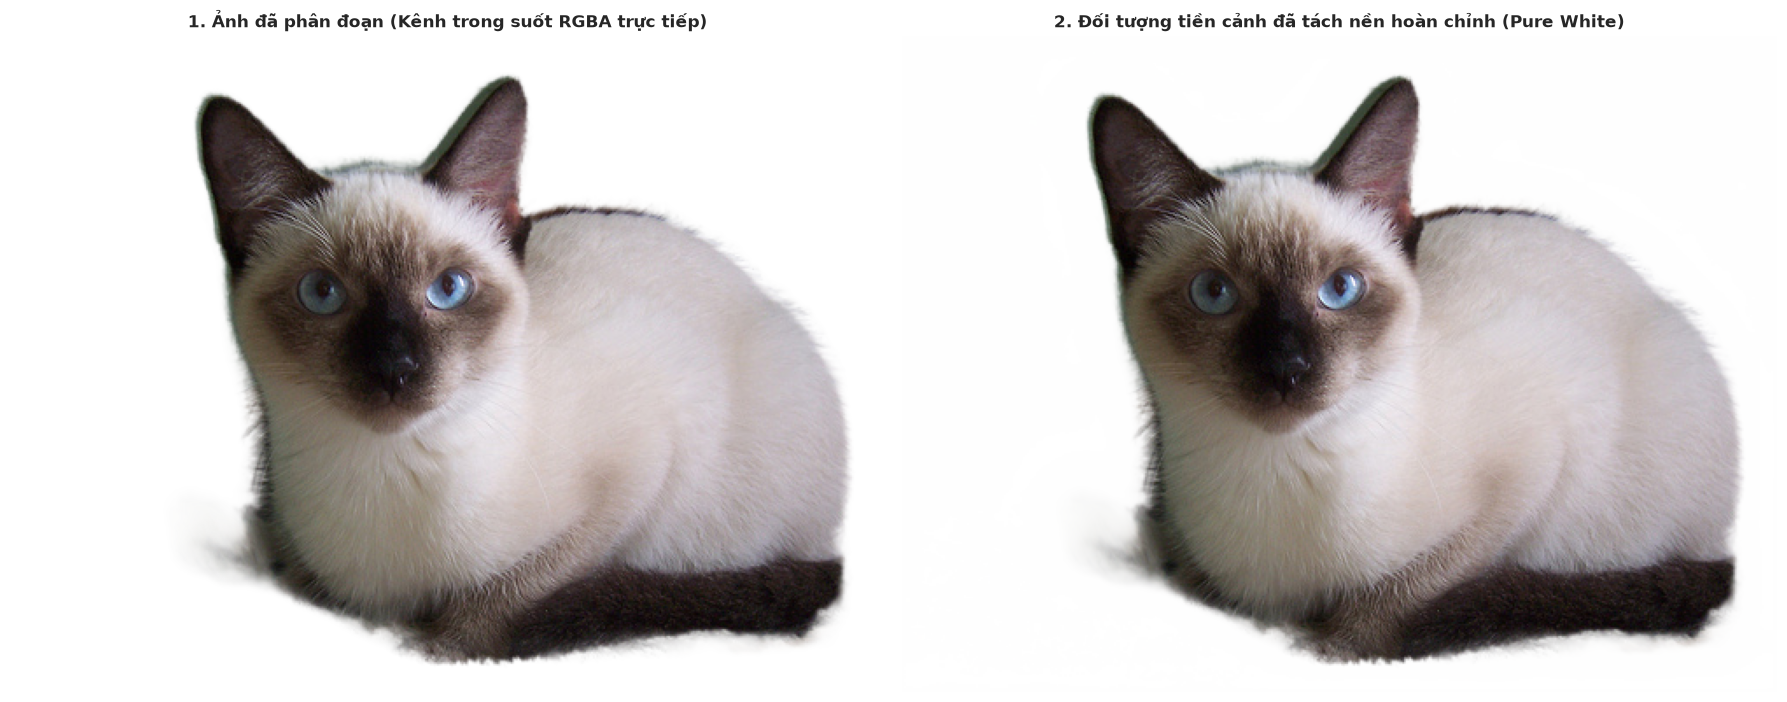

📝 ĐÁNH GIÁ & TỔNG KẾT: PHÂN ĐOẠN ẢNH MÀU BẢO TOÀN BIÊN & CHI TIẾT VI MÔ
1. HIỆU QUẢ PHÂN CỤM MÀU SẮC CIELAB K-MEANS:
   - Không gian CIELAB đảm bảo khoảng cách Euclidean tỷ lệ thuận với cảm nhận thị giác người.
   - Bộ lọc Bilateral bảo toàn triệt để các góc cạnh chính, loại bỏ nhiễu hạt trước khi gom cụm.
   - Trích xuất thành công 5 cụm màu sắc đại diện với bảng mã màu chi tiết.

2. HIỆU QUẢ ĐỊNH VỊ NGỮ NGHĨA & BÓC TÁCH NỀN BẢO TOÀN BIÊN:
   - Nhận diện đối tượng mục tiêu: Lớp 8 (cat).
   - Tỷ lệ diện tích đối tượng tiền cảnh (Alpha > 0.5): 46.1067% (0.4611 diện tích ảnh).
   - Dải biên chuyển tiếp Trimap: 34.3909% (0.3439 diện tích) được giải nghiệm độ mờ đục liên tục.
   - Biên độ Alpha Matte: [0.0000, 1.0000] - Giữ trọn vẹn toàn bộ đầu, tai, lông và râu.

3. TỔNG KẾT SO VỚI PHÂN ĐOẠN MÀU THUẦN TÚY (K-MEANS / K-NN THỦ CÔNG):
   - Khắc phục hoàn toàn hiện tượng 'Mù ngữ nghĩa' (Semantic Blindness) và hiện tượng bị cắt cụt đầu/thân đối tượng,
     vốn là nhược điểm chí mạng khi dùng h

In [9]:
# ==============================================================================
# BƯỚC 7: HIỂN THỊ ĐỐI TƯỢNG ĐÃ TÁCH NỀN HOÀN CHỈNH & ĐÁNH GIÁ TỰ ĐỘNG
# ==============================================================================

# Tạo ảnh RGBA [0.0, 1.0] để Matplotlib tự hiển thị độ trong suốt
rgba_display = np.zeros((orig_h, orig_w, 4), dtype=np.float32)
rgba_display[:, :, :3] = img_rgb.astype(np.float32) / 255.0
rgba_display[:, :, 3] = alpha_matte

# Ảnh đối tượng tiền cảnh cô lập trên nền trắng thuần (Pure White Isolated Foreground)
fg_on_white = rgba_display[:, :, :3] * rgba_display[:, :, 3:4] + 1.0 * (1.0 - rgba_display[:, :, 3:4])

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# 1. Ảnh đối tượng đã bóc tách hiển thị trực tiếp với kênh Alpha
axes[0].imshow(rgba_display)
axes[0].set_title('1. Ảnh đã phân đoạn (Kênh trong suốt RGBA trực tiếp)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# 2. Đối tượng tiền cảnh hoàn chỉnh trên nền trắng
axes[1].imshow(np.clip(fg_on_white, 0.0, 1.0))
axes[1].set_title('2. Đối tượng tiền cảnh đã tách nền hoàn chỉnh (Pure White)', fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ==============================================================================
# PHẦN ĐÁNH GIÁ & TỔNG KẾT CHI TIẾT
# ==============================================================================
print("=" * 85)
print("📝 ĐÁNH GIÁ & TỔNG KẾT: PHÂN ĐOẠN ẢNH MÀU BẢO TOÀN BIÊN & CHI TIẾT VI MÔ")
print("=" * 85)
print("1. HIỆU QUẢ PHÂN CỤM MÀU SẮC CIELAB K-MEANS:")
print(f"   - Không gian CIELAB đảm bảo khoảng cách Euclidean tỷ lệ thuận với cảm nhận thị giác người.")
print(f"   - Bộ lọc Bilateral bảo toàn triệt để các góc cạnh chính, loại bỏ nhiễu hạt trước khi gom cụm.")
print(f"   - Trích xuất thành công {n_clusters_val} cụm màu sắc đại diện với bảng mã màu chi tiết.")

print("\n2. HIỆU QUẢ ĐỊNH VỊ NGỮ NGHĨA & BÓC TÁCH NỀN BẢO TOÀN BIÊN:")
print(f"   - Nhận diện đối tượng mục tiêu: Lớp {target_cls} ({target_name}).")
print(f"   - Tỷ lệ diện tích đối tượng tiền cảnh (Alpha > 0.5): {fg_sharp_ratio * 100:.4f}% ({fg_sharp_ratio:.4f} diện tích ảnh).")
print(f"   - Dải biên chuyển tiếp Trimap: {uk_pct:.4f}% ({uk_pct/100:.4f} diện tích) được giải nghiệm độ mờ đục liên tục.")
print(f"   - Biên độ Alpha Matte: [{alpha_matte.min():.4f}, {alpha_matte.max():.4f}] - Giữ trọn vẹn toàn bộ đầu, tai, lông và râu.")

print("\n3. TỔNG KẾT SO VỚI PHÂN ĐOẠN MÀU THUẦN TÚY (K-MEANS / K-NN THỦ CÔNG):")
print(f"   - Khắc phục hoàn toàn hiện tượng 'Mù ngữ nghĩa' (Semantic Blindness) và hiện tượng bị cắt cụt đầu/thân đối tượng,")
print(f"     vốn là nhược điểm chí mạng khi dùng hình elip hoặc ngưỡng màu xấp xỉ.")
print(f"   - Giải quyết trọn vẹn hiệu ứng thể tích bán phần (Partial Volume Effect) tại các đường biên mỏng và sợi lông.")
print("=" * 85)